#Install JARVIS-Leaderboard: https://github.com/atomgptlab/jarvis_leaderboard

In [2]:
%%time
import os
if not os.path.exists('jarvis_leaderboard'):
  !git clone https://github.com/atomgptlab/jarvis_leaderboard.git
os.chdir('jarvis_leaderboard')
!pip install -q -e .

  Preparing metadata (setup.py) ... done
CPU times: user 1.42 s, sys: 250 ms, total: 1.67 s
Wall time: 14.8 s


In [2]:
!pwd

/content/jarvis_leaderboard


# Populate formation energy-chemical formula dataset

In [3]:
!jarvis_populate_data.py --benchmark_file AI-SinglePropertyPrediction-formula_energy-ssub-test-mae --output_path=Out --json_key formula --id_tag id

/usr/local/bin/jarvis_populate_data.py:4: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  __import__('pkg_resources').require('jarvis-leaderboard==2025.9.3')
benchmark_file AI-SinglePropertyPrediction-formula_energy-ssub-test-mae
dataset ssub
output_path Out
property formula_energy
method AI
task SinglePropertyPrediction
id_tag id
out_format poscar
json_key formula
dataset file to be used /content/jarvis_leaderboard/jarvis_leaderboard/benchmarks/AI/SinglePropertyPrediction/ssub_formula_energy.json.zip
Currently for following  datasets only.
https://atomgptlab.github.io/jarvis/databases/
Obtaining SSUB dataset 1726...
Reference:https://github.com/wolverton-research-group/qmpy
Loading the zipfile...
Loading completed.
number of training samples 1381
number of validation samples 0
number of test samples 345


In [11]:
!ls Out

dataset_info.json  id_prop.csv


In [4]:
from jarvis.db.jsonutils import loadjson
dataset_info = loadjson('Out/dataset_info.json')

In [13]:
dataset_info

{'benchmark_file': 'AI-SinglePropertyPrediction-formula_energy-ssub-test-mae',
 'dataset': 'ssub',
 'output_path': 'Out',
 'prop': 'formula_energy',
 'methods': 'AI',
 'id_tag': 'id',
 'json_key': 'formula',
 'n_train': 1381,
 'n_val': 0,
 'n_test': 345}

In [5]:
import pandas as pd
df = pd.read_csv('Out/id_prop.csv',header=None,names=['formula','form_energy'])
df['id'] = df.index + 1

In [ ]:
df

,formula,form_energy,id
0,CaO4W,-2.841796e+00,1
1,Ho,1.766051e-09,2
2,PbTe,-3.555857e-01,3
3,MoS2,-9.540103e-01,4
4,BeH2,-6.564038e-02,5
...,...,...,...
1721,NZr,-1.892842e+00,1722
1722,CrLiO2,-2.404511e+00,1723
1723,BiNa3,-4.946426e-01,1724
1724,Br4Ge,-7.213532e-01,1725


# Get elemental descriptors https://github.com/atomgptlab/jarvis/blob/master/jarvis/ai/descriptors/elemental.py

In [6]:
from jarvis.ai.descriptors.elemental import get_element_fraction_desc
get_element_fraction_desc('MoS2')

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.66666667, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.33333333, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [7]:
from tqdm import tqdm
tqdm.pandas()
df['desc'] = df['formula'].progress_apply(lambda f: get_element_fraction_desc(f))

100%|██████████| 1726/1726 [00:00<00:00, 79522.92it/s]


In [ ]:
df

,formula,form_energy,id,desc
0,CaO4W,-2.841796e+00,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.66666666..."
1,Ho,1.766051e-09,2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,PbTe,-3.555857e-01,3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,MoS2,-9.540103e-01,4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,BeH2,-6.564038e-02,5,"[0.6666666666666666, 0.0, 0.0, 0.3333333333333..."
...,...,...,...,...
1721,NZr,-1.892842e+00,1722,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, ..."
1722,CrLiO2,-2.404511e+00,1723,"[0.0, 0.0, 0.25, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0,..."
1723,BiNa3,-4.946426e-01,1724,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1724,Br4Ge,-7.213532e-01,1725,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


# Pre-defined train-test split

In [ ]:
train_df=df[:dataset_info['n_train']]
test_df=df[dataset_info['n_train']:]

In [ ]:
len(train_df),len(test_df)

(1381, 345)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
# Note: no hyperparameter tuning here, so model can be further improved in principle
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

# Train model

In [ ]:
import numpy as np
import pickle

# Prepare features and target
X_train = np.array(train_df['desc'].tolist())
y_train = train_df['form_energy'].values

X_test = np.array(test_df['desc'].tolist())
y_test = test_df['form_energy'].values

# Train
rf.fit(X_train, y_train)

# Evaluate
from sklearn.metrics import mean_absolute_error
y_pred = rf.predict(X_test)
print("Test MAE:", mean_absolute_error(y_test, y_pred))

# Pickle the model
with open("rf_form_energy_model.pkl", "wb") as f:
    pickle.dump(rf, f)
print("Model saved to rf_form_energy_model.pkl")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.3s


Test MAE: 0.33841596083284864
Model saved to rf_form_energy_model.pkl


[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    1.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


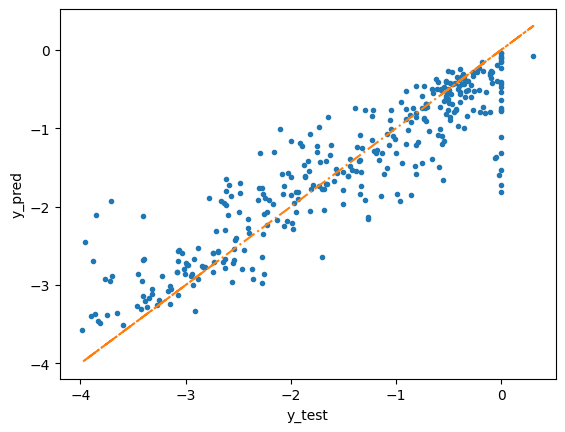

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.plot(y_test, y_pred,'.')
plt.plot(y_test, y_test,'-.')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.show()

# Load pickled model and predict

In [ ]:
import pickle
import numpy as np

# Load the model
with open("rf_form_energy_model.pkl", "rb") as f:
    rf = pickle.load(f)

# Predict on any compound
formula = "SrTiO3MoSWN"  # change to whatever you want
desc = get_element_fraction_desc(formula)
pred = rf.predict([desc])[0]
print(f"{formula}: predicted formation energy = {pred:.4f} eV/atom")

SrTiO3MoSWN: predicted formation energy = -1.9638 eV/atom


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished


In [ ]:
desc

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.11111111, 0.33333333, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.11111111, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.11111111, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.11111111, 0.        , 0.        ,
       0.        , 0.11111111, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.11111111, 0.     

In [ ]:
!ls /content/jarvis_leaderboard/jarvis_leaderboard/

benchmarks     installations		notebooks    specialized_benchmarks.py
contributions  jarvis_populate_data.py	__pycache__  tests
images	       jarvis_serve.py		rebuild.py   Tree.jpg
__init__.py    jarvis_upload.py		scripts      update_metadata.py


In [ ]:
your_jhu_id = 'element_fraction_drkamal_jhu'  # put your id
folder_path = f"/content/jarvis_leaderboard/jarvis_leaderboard/contributions/{your_jhu_id}_tutorial"
if not os.path.exists(folder_path):
    os.makedirs(folder_path, exist_ok=True)
    print(f"Created: {folder_path}")
else:
    print(f"Already exists: {folder_path}")

Created: /content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_drkamal_jhu_tutorial


In [ ]:
test_df

,formula,form_energy,id,desc
1381,I3In,-0.580399,1382,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1382,CuMg2,-0.098870,1383,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1383,BrCs,-2.101874,1384,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1384,B4V3,-0.720463,1385,"[0.0, 0.0, 0.0, 0.0, 0.5714285714285714, 0.0, ..."
1385,Cl3Pt,-0.435810,1386,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...
1721,NZr,-1.892842,1722,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, ..."
1722,CrLiO2,-2.404511,1723,"[0.0, 0.0, 0.25, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0,..."
1723,BiNa3,-0.494643,1724,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1724,Br4Ge,-0.721353,1725,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


# Prepare for JARVIS-Leaderboard submission

In [ ]:
y_pred = rf.predict(X_test)

results = pd.DataFrame({
    'id': test_df['id'].values,
    'formula': test_df['formula'].values,
    'prediction': y_pred,
    'target': test_df['form_energy'].values
})
filename = os.path.join(folder_path, dataset_info['benchmark_file'] + '.csv')
results.to_csv(filename, index=False)

import zipfile
zipname = filename + '.zip'
with zipfile.ZipFile(zipname, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(filename, os.path.basename(filename))

print(f"Saved {filename} with {len(results)} rows")
print(f"Zipped to {zipname}")

Saved /content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_drkamal_jhu_tutorial/AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv with 345 rows
Zipped to /content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_drkamal_jhu_tutorial/AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


In [ ]:
!ls  /content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_drkamal_jhu_tutorial

AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv
AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip


In [ ]:
import json

metadata = {
    "model_name": "Element_fraction_jarvis",
    "project_url": "https://github.com/atomgptlab/jarvis",
    "date_submitted": "04-02-2026",
    "author_email": "xyz@jhu.edu",
    "database_version": "12-12-2022",
    "team_name": "JHU",
    "time_taken_seconds": {
        "AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip": "",
    },
    "language": "python",
    "os": "linux",
    "software_used": "jarvis-tools,numpy,scipy,torch,alignn",
    "hardware_used": "Colab",
    "git_url": []
}
with open(f'{folder_path}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"Saved {folder_path}/metadata.json")

Saved /content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_drkamal_jhu_tutorial/metadata.json


In [ ]:
run_sh = """#!/bin/bash
pip install -q jarvis-tools scikit-learn tqdm

python -c "
import os
import numpy as np
import pickle
import pandas as pd
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from jarvis.db.jsonutils import loadjson
from jarvis.ai.descriptors.elemental import get_element_fraction_desc

# Clone and install
# Setup
os.makedirs('Software', exist_ok=True)
os.chdir('Software')
if not os.path.exists('jarvis_leaderboard'):
    os.system('git clone https://github.com/atomgptlab/jarvis_leaderboard.git')
os.system('pip install -q ./jarvis_leaderboard')
os.chdir('..')

# Populate data
os.system('jarvis_populate_data.py --benchmark_file AI-SinglePropertyPrediction-formula_energy-ssub-test-mae --output_path=Out --json_key formula --id_tag id')

# Load data
dataset_info = loadjson('Out/dataset_info.json')
df = pd.read_csv('Out/id_prop.csv', header=None, names=['formula', 'form_energy'])
df['id'] = df.index + 1

tqdm.pandas()
df['desc'] = df['formula'].progress_apply(lambda f: get_element_fraction_desc(f))

train_df = df[:dataset_info['n_train']]
test_df = df[dataset_info['n_train']:]

# Train
X_train = np.array(train_df['desc'].tolist())
y_train = train_df['form_energy'].values
X_test = np.array(test_df['desc'].tolist())
y_test = test_df['form_energy'].values

rf = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, max_features='sqrt', n_jobs=-1,
    random_state=42, verbose=1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print('Test MAE:', mean_absolute_error(y_test, y_pred))

with open('rf_form_energy_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print('Model saved to rf_form_energy_model.pkl')

# Save results
results = pd.DataFrame({
    'id': test_df['id'].values,
    'formula': test_df['formula'].values,
    'prediction': y_pred,
    'target': test_df['form_energy'].values
})
filename = dataset_info['benchmark_file'] + '.csv'
results.to_csv(filename, index=False)

import zipfile
with zipfile.ZipFile(filename + '.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(filename, filename)
print(f'Saved {filename} and {filename}.zip')
"
"""

with open(f'{folder_path}/run.sh', 'w') as f:
    f.write(run_sh)
print(f"Saved {folder_path}/run.sh")

Saved /content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_drkamal_jhu_tutorial/run.sh


In [ ]:
ls  /content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_drkamal_jhu_tutorial

AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv      metadata.json
AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip  run.sh


# You can fork https://github.com/atomgptlab/jarvis_leaderboard, add the folder such as `element_fraction_drkamal_jhu_tutorial` in jarvis_leaderboard/jarvis_leaderboard/contribution in your fork, send a pull request

In [ ]:
# To rebuild
# %%time
# !python /content/Software/jarvis_leaderboard/jarvis_leaderboard/rebuild.py

# Lets try CFID descriptor based model https://github.com/atomgptlab/jarvis/blob/master/jarvis/ai/descriptors/cfid.py

In [3]:
from jarvis.ai.descriptors.cfid import get_chem_only_descriptors
desc, names = get_chem_only_descriptors('MoS2')

In [4]:
desc, desc.shape

(array([ 1.42635667e+03,  1.05802487e+03,  3.86500000e+00, ...,
        -1.58333333e+00,  1.14733333e-02,  1.41586803e+00]),
 (1314,))

In [15]:
import pandas as pd
df['cfid_desc'] = df['formula'].apply(lambda f: get_chem_only_descriptors(f)[0])

In [16]:
df

,formula,form_energy,id,cfid_desc
0,CaO4W,-2.841796e+00,1,"[624.8266666666667, 441.4676277777778, 1.39246..."
1,Ho,1.766051e-09,2,"[5237.75, 2993.1176, 5.5, -146.19031999999999,..."
2,PbTe,-3.555857e-01,3,"[1351.25, 820.805385, 3.4305000000000003, -74...."
3,MoS2,-9.540103e-01,4,"[1426.3566666666666, 1058.02487, 3.865, -19.93..."
4,BeH2,-6.564038e-02,5,"[481.53999999999996, 463.77515833333337, 0.728..."
...,...,...,...,...
1721,NZr,-1.892842e+00,1722,"[1826.846, 1189.8933875, 1.2855, -19.417675000..."
1722,CrLiO2,-2.404511e+00,1723,"[547.6324999999999, 394.9703666666667, 1.7375,..."
1723,BiNa3,-4.946426e-01,1724,"[1147.7, 663.1486325000001, 2.9460000000000006..."
1724,Br4Ge,-7.213532e-01,1725,"[539.345, 442.15808, 5.788600000000001, -29.95..."


In [17]:
train_df=df[:dataset_info['n_train']]
test_df=df[dataset_info['n_train']:]
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
import numpy as np
import pickle

# Prepare features and target
X_train = np.array(train_df['cfid_desc'].tolist())
y_train = train_df['form_energy'].values

X_test = np.array(test_df['cfid_desc'].tolist())
y_test = test_df['form_energy'].values

# Train
rf.fit(X_train, y_train)

# Evaluate
from sklearn.metrics import mean_absolute_error
y_pred = rf.predict(X_test)
print("Test MAE:", mean_absolute_error(y_test, y_pred))

# Pickle the model
with open("rf_form_energy_model_cfid.pkl", "wb") as f:
    pickle.dump(rf, f)
print("Model saved to rf_form_energy_model_cfid.pkl")


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    8.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s


Test MAE: 0.21868670626959397
Model saved to rf_form_energy_model_cfid.pkl


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


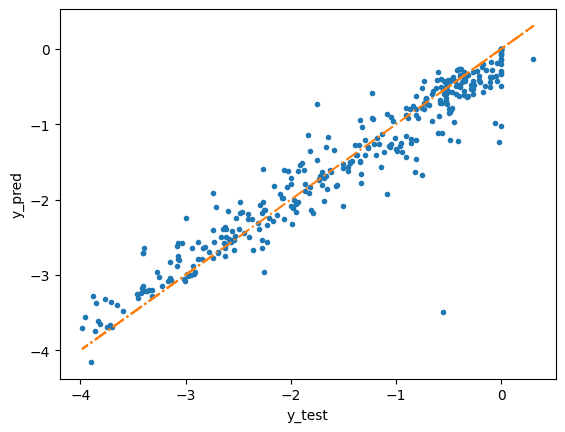

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.plot(y_test, y_pred,'.')
plt.plot(y_test, y_test,'-.')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.show()

In [19]:
import pickle
import numpy as np

# Load the model
with open("rf_form_energy_model_cfid.pkl", "rb") as f:
    rf = pickle.load(f)

# Predict on any compound
formula = "SrTiO3MoSWN"  # change to whatever you want
desc = get_chem_only_descriptors(formula)[0]
pred = rf.predict([desc])[0]
print(f"{formula}: predicted formation energy = {pred:.4f} eV/atom")

SrTiO3MoSWN: predicted formation energy = -1.6323 eV/atom


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


In [8]:
# QUESTION 1

your_jhu_id = 'element_fraction_ptomar_jhu'  # put your id
folder_path = f"/content/jarvis_leaderboard/jarvis_leaderboard/contributions/{your_jhu_id}_tutorial"
if not os.path.exists(folder_path):
    os.makedirs(folder_path, exist_ok=True)
    print(f"Created: {folder_path}")
else:
    print(f"Already exists: {folder_path}")

Already exists: /content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_ptomar_jhu_tutorial


In [26]:
cd element_fraction_ptomar_jhu_tutorial/

/content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_ptomar_jhu_tutorial


In [27]:
from jarvis.ai.descriptors.elemental import get_element_fraction_desc
get_element_fraction_desc('MoS2')

from tqdm import tqdm
tqdm.pandas()
df['desc'] = df['formula'].progress_apply(lambda f: get_element_fraction_desc(f))

train_df=df[:dataset_info['n_train']]
test_df=df[dataset_info['n_train']:]

from sklearn.ensemble import RandomForestRegressor

# Note: no hyperparameter tuning here, so model can be further improved in principle

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

import numpy as np
import pickle

# Prepare features and target
X_train = np.array(train_df['desc'].tolist())
y_train = train_df['form_energy'].values

X_test = np.array(test_df['desc'].tolist())
y_test = test_df['form_energy'].values

# Train
rf.fit(X_train, y_train)

# Evaluate
from sklearn.metrics import mean_absolute_error
y_pred = rf.predict(X_test)
print("Test MAE:", mean_absolute_error(y_test, y_pred))

# Pickle the model
with open("rf_form_energy_model.pkl", "wb") as f:
    pickle.dump(rf, f)
print("Model saved to rf_form_energy_model.pkl")

100%|██████████| 1726/1726 [00:00<00:00, 89946.81it/s]
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.2s


Test MAE: 0.33841596083284864
Model saved to rf_form_energy_model.pkl


[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


In [28]:
! ls

AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv
AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip
metadata.json
rf_form_energy_model.pkl
run.sh


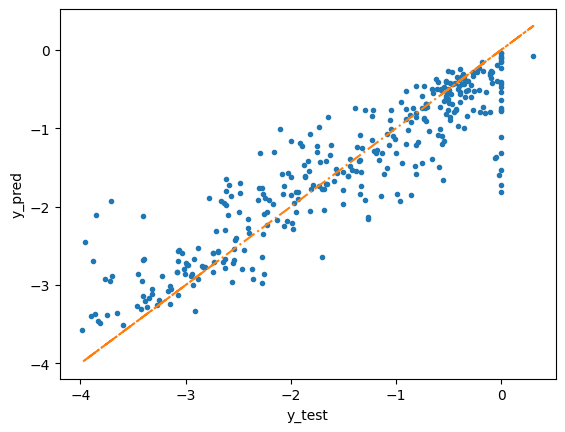

SrTiO3MoSWN: predicted formation energy = -1.9638 eV/atom


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


In [29]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.plot(y_test, y_pred,'.')
plt.plot(y_test, y_test,'-.')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.show()

import pickle
import numpy as np

# Load the model
with open("rf_form_energy_model.pkl", "rb") as f:
    rf = pickle.load(f)

# Predict on any compound
formula = "SrTiO3MoSWN"  # change to whatever you want
desc = get_element_fraction_desc(formula)
pred = rf.predict([desc])[0]
print(f"{formula}: predicted formation energy = {pred:.4f} eV/atom")

In [30]:
y_pred = rf.predict(X_test)

results = pd.DataFrame({
    'id': test_df['id'].values,
    'formula': test_df['formula'].values,
    'prediction': y_pred,
    'target': test_df['form_energy'].values
})
filename = os.path.join(folder_path, dataset_info['benchmark_file'] + '.csv')
results.to_csv(filename, index=False)

import zipfile
zipname = filename + '.zip'
with zipfile.ZipFile(zipname, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(filename, os.path.basename(filename))

print(f"Saved {filename} with {len(results)} rows")
print(f"Zipped to {zipname}")

Saved /content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_ptomar_jhu_tutorial/AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv with 345 rows
Zipped to /content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_ptomar_jhu_tutorial/AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


In [31]:
! ls

AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv
AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip
metadata.json
rf_form_energy_model.pkl
run.sh


In [32]:
import json

metadata = {
    "model_name": "Element_fraction_jarvis",
    "project_url": "https://github.com/atomgptlab/jarvis",
    "date_submitted": "04-02-2026",
    "author_email": "xyz@jhu.edu",
    "database_version": "12-12-2022",
    "team_name": "JHU",
    "time_taken_seconds": {
        "AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip": "",
    },
    "language": "python",
    "os": "linux",
    "software_used": "jarvis-tools,numpy,scipy,torch,alignn",
    "hardware_used": "Colab",
    "git_url": []
}
with open(f'{folder_path}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"Saved {folder_path}/metadata.json")

Saved /content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_ptomar_jhu_tutorial/metadata.json


In [33]:
run_sh = """#!/bin/bash
pip install -q jarvis-tools scikit-learn tqdm

python -c "
import os
import numpy as np
import pickle
import pandas as pd
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from jarvis.db.jsonutils import loadjson
from jarvis.ai.descriptors.elemental import get_element_fraction_desc

# Clone and install
# Setup
os.makedirs('Software', exist_ok=True)
os.chdir('Software')
if not os.path.exists('jarvis_leaderboard'):
    os.system('git clone https://github.com/atomgptlab/jarvis_leaderboard.git')
os.system('pip install -q ./jarvis_leaderboard')
os.chdir('..')

# Populate data
os.system('jarvis_populate_data.py --benchmark_file AI-SinglePropertyPrediction-formula_energy-ssub-test-mae --output_path=Out --json_key formula --id_tag id')

# Load data
dataset_info = loadjson('Out/dataset_info.json')
df = pd.read_csv('Out/id_prop.csv', header=None, names=['formula', 'form_energy'])
df['id'] = df.index + 1

tqdm.pandas()
df['desc'] = df['formula'].progress_apply(lambda f: get_element_fraction_desc(f))

train_df = df[:dataset_info['n_train']]
test_df = df[dataset_info['n_train']:]

# Train
X_train = np.array(train_df['desc'].tolist())
y_train = train_df['form_energy'].values
X_test = np.array(test_df['desc'].tolist())
y_test = test_df['form_energy'].values

rf = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, max_features='sqrt', n_jobs=-1,
    random_state=42, verbose=1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print('Test MAE:', mean_absolute_error(y_test, y_pred))

with open('rf_form_energy_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print('Model saved to rf_form_energy_model.pkl')

# Save results
results = pd.DataFrame({
    'id': test_df['id'].values,
    'formula': test_df['formula'].values,
    'prediction': y_pred,
    'target': test_df['form_energy'].values
})
filename = dataset_info['benchmark_file'] + '.csv'
results.to_csv(filename, index=False)

import zipfile
with zipfile.ZipFile(filename + '.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(filename, filename)
print(f'Saved {filename} and {filename}.zip')
"
"""

with open(f'{folder_path}/run.sh', 'w') as f:
    f.write(run_sh)
print(f"Saved {folder_path}/run.sh")

Saved /content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_ptomar_jhu_tutorial/run.sh


In [34]:
! ls

AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv
AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip
metadata.json
rf_form_energy_model.pkl
run.sh


In [119]:
! pwd

/content/jarvis_leaderboard/jarvis_leaderboard/contributions/element_fraction_ptomar_jhu_tutorial


In [129]:
! ls

AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv
AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip
metadata.json
rf_form_energy_model.pkl
run.sh


In [130]:
! cd ..

/content/jarvis_leaderboard/jarvis_leaderboard/contributions


In [131]:
! zip -r element_fraction_ptomar_jhu_tutorial.zip element_fraction_ptomar_jhu_tutorial/

  adding: element_fraction_ptomar_jhu_tutorial/ (stored 0%)
  adding: element_fraction_ptomar_jhu_tutorial/metadata.json (deflated 39%)
  adding: element_fraction_ptomar_jhu_tutorial/AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv (deflated 49%)
  adding: element_fraction_ptomar_jhu_tutorial/AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip (stored 0%)
  adding: element_fraction_ptomar_jhu_tutorial/rf_form_energy_model.pkl (deflated 72%)
  adding: element_fraction_ptomar_jhu_tutorial/run.sh (deflated 53%)


In [136]:
from google.colab import files
files.download('element_fraction_ptomar_jhu_tutorial.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
# QUESTION 2

!!pip install fastapi uvicorn nest_asyncio

['Requirement already satisfied: fastapi in /usr/local/lib/python3.12/dist-packages (0.135.2)',
 'Requirement already satisfied: uvicorn in /usr/local/lib/python3.12/dist-packages (0.42.0)',
 'Requirement already satisfied: nest_asyncio in /usr/local/lib/python3.12/dist-packages (1.6.0)',
 'Requirement already satisfied: starlette>=0.46.0 in /usr/local/lib/python3.12/dist-packages (from fastapi) (0.52.1)',
 'Requirement already satisfied: pydantic>=2.9.0 in /usr/local/lib/python3.12/dist-packages (from fastapi) (2.12.3)',
 'Requirement already satisfied: typing-extensions>=4.8.0 in /usr/local/lib/python3.12/dist-packages (from fastapi) (4.15.0)',
 'Requirement already satisfied: typing-inspection>=0.4.2 in /usr/local/lib/python3.12/dist-packages (from fastapi) (0.4.2)',
 'Requirement already satisfied: annotated-doc>=0.0.2 in /usr/local/lib/python3.12/dist-packages (from fastapi) (0.0.4)',
 'Requirement already satisfied: click>=7.0 in /usr/local/lib/python3.12/dist-packages (from uvic

In [36]:
# app.py
import nest_asyncio
import uvicorn
from fastapi import FastAPI
import threading

# Patch event loop so uvicorn can run inside Colab's existing loop
nest_asyncio.apply()

app = FastAPI()

In [157]:
! cd element_fraction_ptomar_jhu_tutorial

In [37]:
ls

AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv
AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip
metadata.json
rf_form_energy_model.pkl
run.sh


In [38]:
import pickle
with open("rf_form_energy_model.pkl","rb") as f:
  model = pickle.load(f)

In [39]:
import pickle
with open("rf_form_energy_model.pkl","rb") as f:
  obj = pickle.load(f)

In [40]:
# GET — retrieve data, no side effects, params go in the URL
# Example: http://localhost:8000/
@app.get("/")
def root():
    return {"message": "Hello from FastAPI on Colab!"}

# GET with query parameter — passed as ?formula=GaN in the URL
# Example: http://localhost:8000/predict?formula=GaN

#@app.get("/predict")
#def predict(formula: str = "Si"):
    #desc = get_element_fraction_desc(formula)
    #pred = model.predict([desc])[0]
    #return {"formula": formula, "predicted_property": form_energy}

@app.get("/predict")
def predict(formula: str):
    desc = get_element_fraction_desc(formula)
    pred = rf.predict([desc])[0]
    return {"formula": formula, "predicted_form_energy": float(pred)}

# POST — send data in the request body (JSON), used for creating/submitting
# Example: curl -X POST ... -d '{"formula":"GaN"}'
# @app.post("/predict_post")

# PUT — update/replace an existing resource entirely
# PATCH — partially update an existing resource
# DELETE — remove a resource

# Start server in background so the notebook stays interactive
def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run, daemon=True)
thread.start()

# Visit http://localhost:8000/docs for auto-generated Swagger UI

In [41]:
import requests

r = requests.get("http://localhost:8000/")
print(r.json())

r = requests.get("http://localhost:8000/predict?formula=GaN")
print(r.json())

INFO:     127.0.0.1:54044 - "GET / HTTP/1.1" 200 OK
{'message': 'Hello from FastAPI on Colab!'}
INFO:     127.0.0.1:54048 - "GET /predict?formula=GaN HTTP/1.1" 200 OK
{'formula': 'GaN', 'predicted_form_energy': -1.2009268580029282}


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


In [42]:
! curl -s "http://localhost:8000/predict?formula=AlGaN" | python3 -m json.tool

INFO:     127.0.0.1:54056 - "GET /predict?formula=AlGaN HTTP/1.1" 200 OK


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.2s finished


{
    "formula": "AlGaN",
    "predicted_form_energy": -0.8301175790575428
}
